In [1]:
!pip install kagglehub


In [2]:
import os, shutil, kagglehub
from sklearn.model_selection import train_test_split

print("Đang tải PlantVillage Dataset từ Kaggle...")
dataset_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
source_dir = os.path.join(dataset_path, "plantvillage dataset", "color")
if not os.path.exists(source_dir): source_dir = dataset_path

base_dir = 'data'
if os.path.exists(base_dir): shutil.rmtree(base_dir)
train_dir, val_dir, test_dir = os.path.join(base_dir, 'train'), os.path.join(base_dir, 'val'), os.path.join(base_dir, 'test')
for d in [train_dir, val_dir, test_dir]: os.makedirs(d, exist_ok=True)

classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
for cls in classes:
    for d in [train_dir, val_dir, test_dir]: os.makedirs(os.path.join(d, cls), exist_ok=True)
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.JPG', '.png', '.jpeg'))]
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for img in train_imgs: shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs: shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))
    for img in test_imgs: shutil.copy(os.path.join(cls_path, img), os.path.join(test_dir, cls, img))

print("✅ Đã chia xong dữ liệu vào thư mục data/ (Train: 70%, Val: 15%, Test: 15%)")


Đang tải PlantVillage Dataset từ Kaggle...
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
✅ Đã chia xong dữ liệu vào thư mục data/ (Train: 70%, Val: 15%, Test: 15%)


Found 37998 images belonging to 38 classes.
Found 8145 images belonging to 38 classes.
Found 8162 images belonging to 38 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 614s 504ms/step - accuracy: 0.7564 - loss: 0.8516 - val_accuracy: 0.9150 - val_loss: 0.2739
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 596s 489ms/step - accuracy: 0.8672 - loss: 0.4157 - val_accuracy: 0.9298 - val_loss: 0.2060
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 578s 487ms/step - accuracy: 0.8833 - loss: 0.3613 - val_accuracy: 0.9306 - val_loss: 0.2004
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 584s 492ms/step - accuracy: 0.8897 - loss: 0.3408 - val_accuracy: 0.9152 - val_loss: 0.2634
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 613s 515ms/step - accuracy: 0.8912 - loss: 0.3480 - val_accuracy: 0.9449 - val_loss: 0.1612
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 573s 482ms/step - accuracy: 0.9001 - loss: 0.3055 - val_accuracy: 0.9421 - val_loss: 0.1603
Epoch 7/10
1188


✅ Đã lưu lịch sử huấn luyện vào results/resnet50_history.csv
256/256 ━━━━━━━━━━━━━━━━━━━━ 33s 128ms/step - accuracy: 0.9876 - loss: 0.0434
Test accuracy: 0.9876
256/256 ━━━━━━━━━━━━━━━━━━━━ 37s 126ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00        95
                                 Apple___Black_rot       1.00      1.00      1.00        94
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        42
                                   Apple___healthy       0.98      1.00      0.99       247
                               Blueberry___healthy       1.00      1.00      1.00       226
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       158
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       

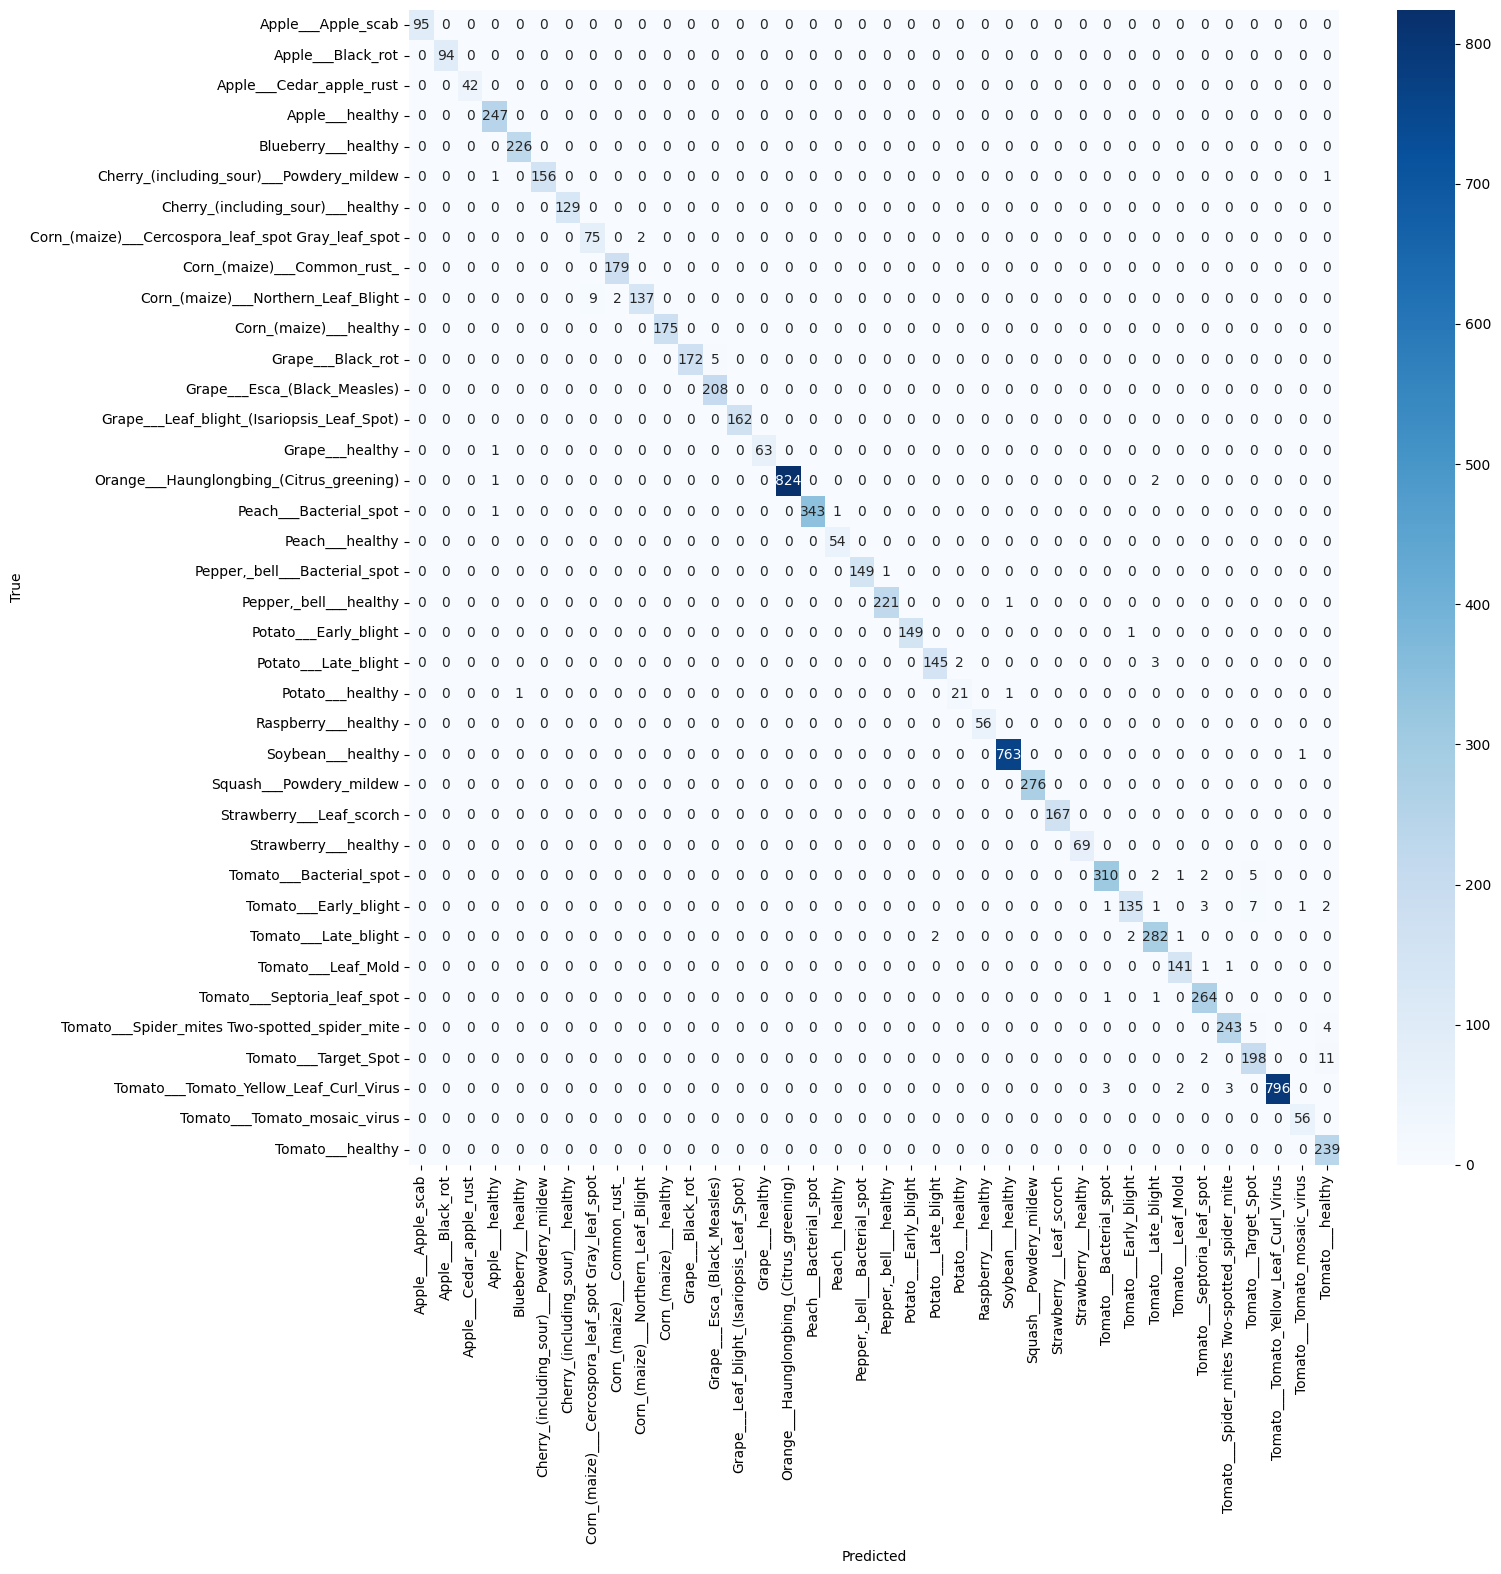

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# 1️⃣ Cấu hình chung
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_PHASE_1 = 10
EPOCHS_PHASE_2 = 10

# 2️⃣ Data augmentation và preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load data từ thư mục
train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = test_val_datagen.flow_from_directory(
    'data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_val_datagen.flow_from_directory(
    'data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)

# 3️⃣ Tính Class Weights cho dữ liệu mất cân bằng
train_labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights_array))

# 4️⃣ Build model with transfer learning (Phase 1)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Phase 1
history1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE_1,
    validation_data=val_generator,
    class_weight=class_weight_dict
)

# 5️⃣ Fine-tuning (Phase 2)
base_model.trainable = True

# Mở băng 30 lớp cuối
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Compile lại với learning_rate rất nhỏ
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Phase 2
history2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE_2,
    validation_data=val_generator,
    class_weight=class_weight_dict
)

model.save('resnet50_finetuned_model.h5')

# Lưu lịch sử huấn luyện (Loss, Accuracy) ra file CSV
history_df1 = pd.DataFrame(history1.history)
history_df2 = pd.DataFrame(history2.history)
history_df = pd.concat([history_df1, history_df2], ignore_index=True)
os.makedirs('results', exist_ok=True)
history_df.to_csv('results/resnet50_history.csv', index=False)
print("\n✅ Đã lưu lịch sử huấn luyện vào results/resnet50_history.csv")

# 6️⃣ Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

# Vẽ đồ thị Accuracy
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(8, 6))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=EPOCHS_PHASE_1 - 1, color='r', linestyle='--', label='Bắt đầu Fine-tuning')
plt.title('Đồ thị Accuracy')
plt.legend()
os.makedirs('results', exist_ok=True)
plt.savefig('results/resnet50_accuracy.png')
plt.close()

# Vẽ đồ thị Loss
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(8, 6))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=EPOCHS_PHASE_1 - 1, color='r', linestyle='--', label='Bắt đầu Fine-tuning')
plt.title('Đồ thị Loss')
plt.legend()
plt.savefig('results/resnet50_loss.png')
plt.close()

# 7️⃣ F1-score & Confusion Matrix
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('results/resnet50_confusion_matrix.png')
print("✅ QUÁ TRÌNH HUẤN LUYỆN HOÀN TẤT, HÃY TẢI ẢNH/FILE TỪ THƯ MỤC 'RESULTS' VỀ MÁY!")
